## Assignment 3: Pattern Mining and Recommender Systems

### Aryan Moradi, A1779263, Version 04

In [4]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from collections import defaultdict
from itertools import combinations
from datetime import datetime, timedelta

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
train_path = '/content/drive/MyDrive/big data mining/assignment 3/Groceries data train.csv'
test_path  = '/content/drive/MyDrive/big data mining/assignment 3/Groceries data test.csv'
train_df  = pd.read_csv(train_path)
test_df   = pd.read_csv(test_path)

# Exploratory Data Analysis (EDA)

In [7]:
train_df = train_df.rename(columns={"User_id": "user_id"})

In [8]:
train_df["Date"] = pd.to_datetime(train_df["Date"], format='%d/%m/%Y')

test_df["Date"] = pd.to_datetime(test_df["Date"], format='%d/%m/%Y')

In [9]:
print("Train shape:", train_df.shape)
print("Test  shape:", test_df.shape)
print("\nColumns:", list(train_df.columns))
print("\nMissing values (train):\n", train_df.isna().sum())
print("\nMissing values (test):\n", test_df.isna().sum())

Train shape: (26985, 7)
Test  shape: (19383, 7)

Columns: ['user_id', 'Date', 'itemDescription', 'year', 'month', 'day', 'day_of_week']

Missing values (train):
 user_id            7603
Date               7603
itemDescription    7603
year               7603
month              7603
day                7603
day_of_week        7603
dtype: int64

Missing values (test):
 user_id            0
Date               0
itemDescription    0
year               0
month              0
day                0
day_of_week        0
dtype: int64


In [10]:
train_daily = train_df.groupby('Date').size().reset_index(name='Transactions')
test_daily = test_df.groupby('Date').size().reset_index(name='Transactions')

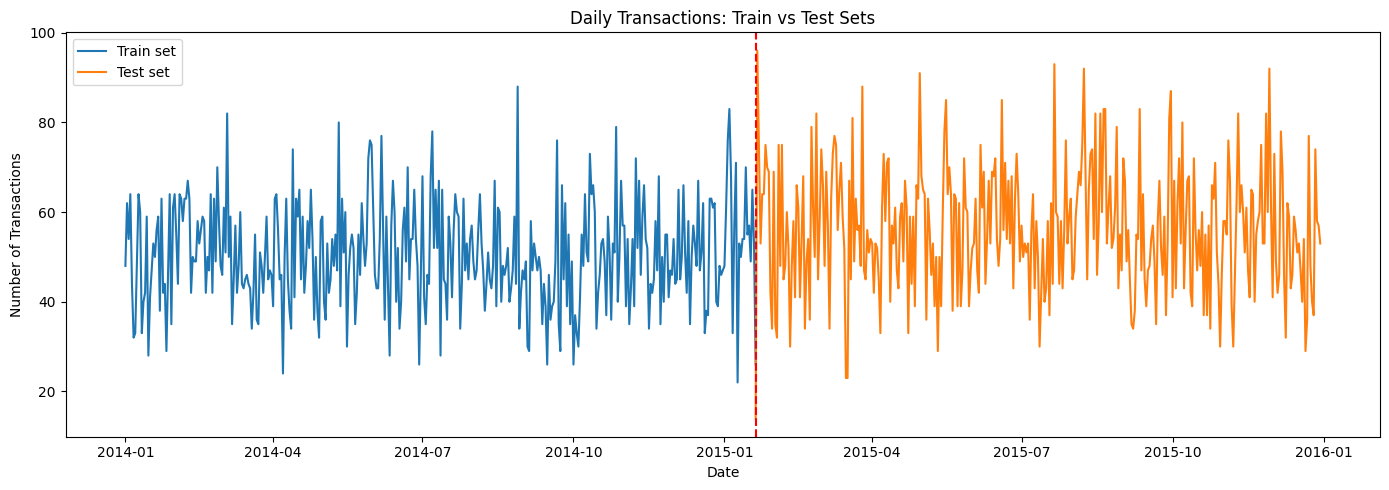

In [11]:
plt.figure(figsize=(14, 5))
plt.plot(train_daily['Date'], train_daily['Transactions'], label='Train set')
plt.plot(test_daily['Date'], test_daily['Transactions'], label='Test set')

plt.title('Daily Transactions: Train vs Test Sets')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.legend()
plt.axvline(x=test_daily['Date'].min(), color='r', linestyle='--', label='Train/Test Split')
plt.tight_layout()
plt.show()

In [12]:
top20_train = train_df["itemDescription"].value_counts().head(20)
top20_test  = test_df["itemDescription"].value_counts().head(20)

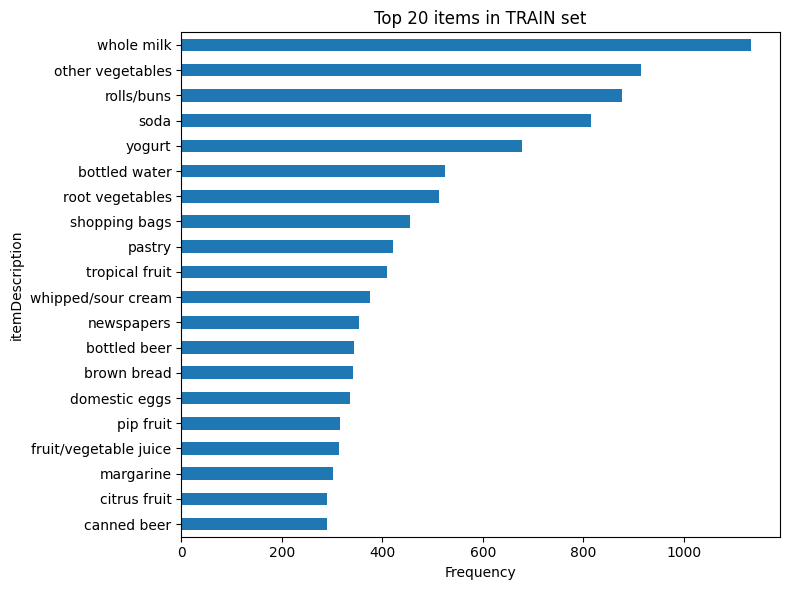

In [13]:
fig, ax = plt.subplots(figsize=(8,6))
top20_train[::-1].plot(kind="barh", ax=ax)
ax.set_title("Top 20 items in TRAIN set")
ax.set_xlabel("Frequency")
plt.tight_layout()
plt.show()

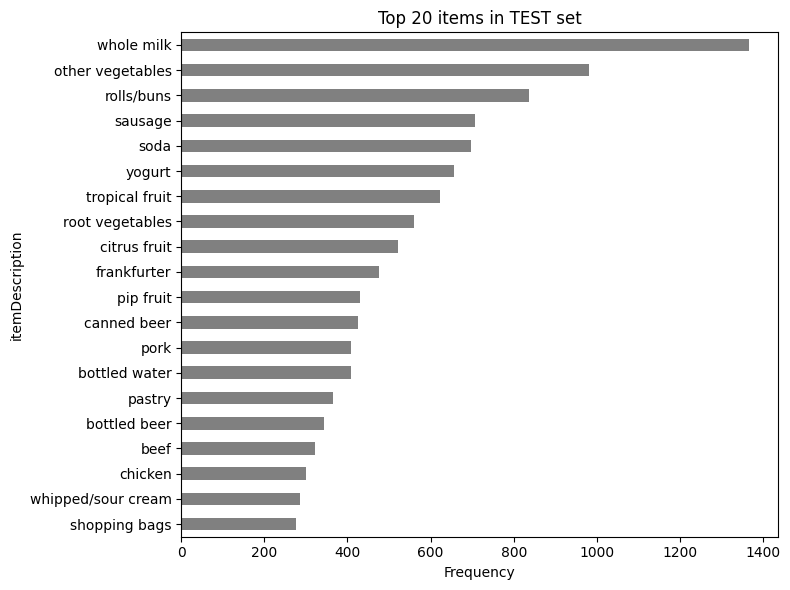

In [14]:
fig, ax = plt.subplots(figsize=(8,6))
top20_test[::-1].plot(kind="barh", ax=ax, color="grey")
ax.set_title("Top 20 items in TEST set")
ax.set_xlabel("Frequency")
plt.tight_layout()
plt.show()

In [15]:
n_users_train = train_df["user_id"].nunique()
n_users_test  = test_df["user_id"].nunique()
print(f"Unique users in 2014 (train): {n_users_train:,}")
print(f"Unique users in 2015 (test):  {n_users_test:,}")

Unique users in 2014 (train): 3,493
Unique users in 2015 (test):  3,231


In [16]:
items_per_user = train_df.groupby("user_id")["itemDescription"].count()

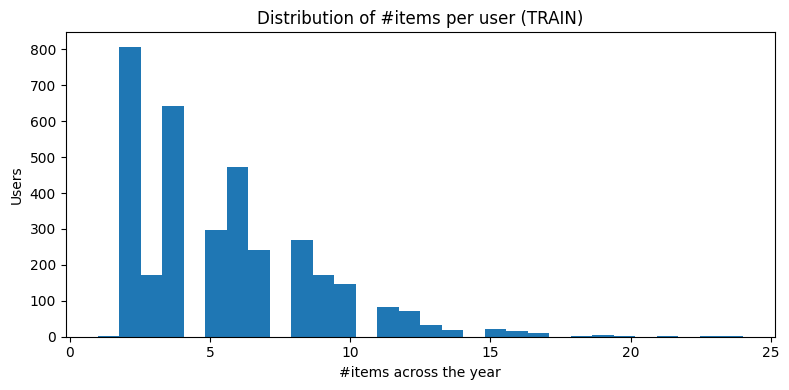

In [17]:
plt.figure(figsize=(8,4))
plt.hist(items_per_user, bins=30)
plt.title("Distribution of #items per user (TRAIN)")
plt.xlabel("#items across the year")
plt.ylabel("Users")
plt.tight_layout()
plt.show()

In [18]:
dow_map = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
train_dow = train_df["day_of_week"].value_counts().sort_index()
test_dow  = test_df["day_of_week"].value_counts().sort_index()

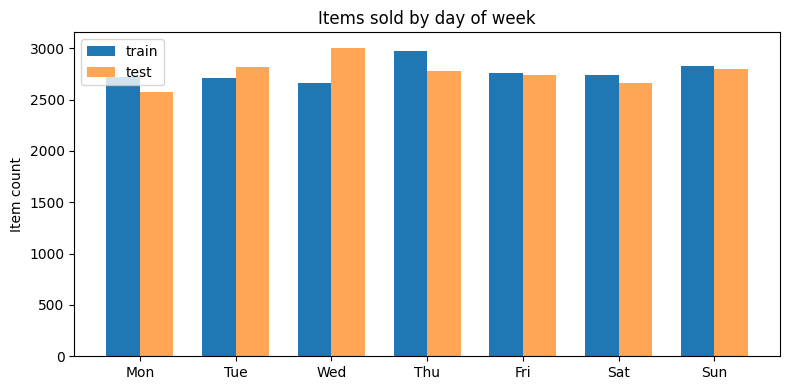

In [19]:
x = np.arange(7)
width = 0.35
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x - width/2, train_dow.values, width, label="train")
ax.bar(x + width/2, test_dow.values,  width, label="test", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(dow_map)
ax.set_title("Items sold by day of week")
ax.set_ylabel("Item count")
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
train_baskets = (
    train_df
      .groupby(["user_id", "Date"])
      .size()
      .reset_index(name="items_in_basket")
)

In [21]:
baskets_per_user = train_baskets.groupby("user_id").size()

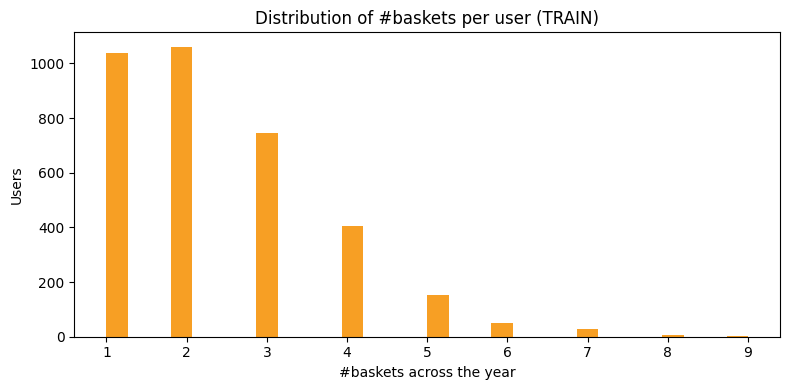

In [22]:
plt.figure(figsize=(8,4))
plt.hist(baskets_per_user, bins=30, color="#F79F24")
plt.title("Distribution of #baskets per user (TRAIN)")
plt.xlabel("#baskets across the year")
plt.ylabel("Users")
plt.tight_layout()
plt.show()

## Frequent Pattern Mininig

In [23]:
class AprioriMiner:
    def __init__(self, min_support=0.005):
        self.min_support = min_support
        self.transactions = None
        self.num_transactions = 0
        self.frequent_itemsets = {}
        self.item_support = {}

    # Find all frequent subsets
    def fit(self, transactions):
        """
        Find frequent itemsets using the Apriori algorithm.

        Parameters:
        -----------
        transactions : list of lists
            List of transactions, where each transaction is a list of items

        Returns:
        --------
        dict
            Dictionary with keys as itemset size and values as list of (itemset, support) tuples
        """
        self.transactions = transactions
        self.num_transactions = len(transactions)

        # Step 1: Count support for each individual item
        item_counts = defaultdict(int)
        for transaction in transactions:
            for item in set(transaction):  # Use set to count each item once per transaction
                item_counts[item] += 1

        # Filter by minimum support
        min_count = self.min_support * self.num_transactions
        self.item_support = {item: count/self.num_transactions for item, count in item_counts.items()
                           if count >= min_count}

        # Initialize L1 (frequent 1-itemsets)
        L1 = [frozenset([item]) for item in self.item_support.keys()]
        current_L = L1
        k = 1

        # Store all frequent itemsets
        self.frequent_itemsets = {
            k: [(itemset, self.item_support[list(itemset)[0]]) for itemset in L1]
        }
        # ========================
        # Main Apriori loop
        while current_L:
            k += 1
            # Generate candidate k-itemsets
            Ck = self._generate_candidates(current_L, k)

            if not Ck:
                break  # No candidates generated

            # Count support for candidates
            itemset_counts = defaultdict(int)
            for transaction in transactions:
                transaction_set = set(transaction)
                for candidate in Ck:
                    if candidate.issubset(transaction_set):
                        itemset_counts[candidate] += 1

            # Filter by minimum support
            Lk = [itemset for itemset, count in itemset_counts.items()
                 if count >= min_count]

            # Store k-itemsets with their support
            if Lk:
                self.frequent_itemsets[k] = [(itemset, itemset_counts[itemset]/self.num_transactions)
                                           for itemset in Lk]

            # Prepare for next iteration
            current_L = Lk

        return self.frequent_itemsets

    def _generate_candidates(self, prev_itemsets, k):
        """Generate candidate k-itemsets from (k-1)-itemsets"""
        candidates = set()

        # For more efficient processing, convert to list of sets
        prev_sets = [set(itemset) for itemset in prev_itemsets]

        # For each pair of (k-1)-itemsets
        for i in range(len(prev_sets)):
            for j in range(i+1, len(prev_sets)):
                # Join step
                union = prev_sets[i].union(prev_sets[j])
                if len(union) == k:
                    # Check if all (k-1) subsets are frequent
                    is_valid = True
                    for item in union: # get subset including (k-1) items from current k-item set
                        subset = union - {item}
                        # If one of the subset of the current set is NOT frequent
                        if frozenset(subset) not in prev_itemsets: #[frozenset(s) for s in prev_itemsets]:
                            is_valid = False
                            break

                    if is_valid:
                        candidates.add(frozenset(union))
        # Return all sets having k items whose all (k-1) subsets frequent
        return list(candidates)

    def generate_rules(self, min_confidence=0.5):
        """
        Generate association rules from frequent itemsets.

        Parameters:
        -----------
        min_confidence : float, default=0.5
            Minimum confidence threshold for rules

        Returns:
        --------
        list
            List of (antecedent, consequent, support, confidence, lift) tuples
        """
        rules = []

        # Helper function to find support for an itemset
        def find_support(itemset):
            k = len(itemset)
            # for k in self.frequent_itemsets:
            for (candidate, support) in self.frequent_itemsets[k]:
                if candidate == itemset:
                    return support
            return 0  # Should not happen for frequent itemsets

        # For each k-itemset where k >= 2
        for k in self.frequent_itemsets:
            # Cannot create rules with a set of only 1 item
            if k < 2:
                continue
            # print('hi')
            for itemset, itemset_support in self.frequent_itemsets[k]:

                # Generate all non-empty proper subsets
                subsets = []
                for i in range(1, k):
                    subsets.extend([frozenset(subset) for subset in combinations(itemset, i)])
                # print(subsets)
                # For each subset, create a rule
                for antecedent in subsets: # Take the subsets array as array of all entecedents => itemset - antecedent = consequent set
                    consequent = itemset - antecedent

                    # Skip empty consequents
                    if not consequent:
                        continue

                    # A=>B: Calculate CONFIDENCE P(A, B) / P(A)
                    antecedent_support = find_support(antecedent)
                    confidence = itemset_support / antecedent_support

                    if confidence >= min_confidence:
                        # A= > B: Calculate LIFT P(A, B) /(P(A)*P(B))
                        consequent_support = find_support(consequent)
                        lift = confidence / consequent_support

                        rules.append({
                            'antecedent': list(antecedent),
                            'consequent': list(consequent),
                            'support': itemset_support,
                            'confidence': confidence,
                            'lift': lift
                        })

        return rules

In [24]:
class PatternScorer:
    """
    PatternScorer evaluates frequent itemsets from market basket analysis.

    This class provides methods to score patterns using various metrics including
    support, lift, recency, and combinations of these metrics. It can also personalize
    recommendations based on user purchase history.
    """
    def __init__(self, transactions, frequent_itemsets, item_support):
        """
        Initialize the PatternScorer with transaction data and frequent itemsets.

        Parameters:
        -----------
        transactions : list
            List of transactions where each transaction is a set of items
        frequent_itemsets : dict
            Dictionary mapping k (itemset size) to list of (itemset, support) tuples
        item_support : dict
            Dictionary mapping individual items to their support values
        """
        self.transactions = transactions
        self.frequent_itemsets = frequent_itemsets
        self.item_support = item_support
        self.user_data = None

    def add_user_data(self, data):
        """
        Add user-specific data for personalized scoring.

        This method processes user transaction data to calculate:
        1. How frequently each user buys each item
        2. When each user last purchased each item

        Parameters:
        -----------
        data : DataFrame
            DataFrame containing user purchase history with User_id, itemDescription, and Date columns
        """
        self.user_data = data

        # Initialize dictionaries to track user purchase patterns
        # user_item_frequencies: How many times each user bought each item
        self.user_item_frequencies = defaultdict(lambda: defaultdict(int))
        #This dictionary stores user's latest date making purchase on each item
        self.user_last_purchase = defaultdict(lambda: defaultdict(str))

        # Group data by user
        for _, row in data.iterrows():
            user = row['user_id']
            item = row['itemDescription']
            date = row['Date']

            # FOREACH USER FOREACH ITEM: store how many time they purchased that item and the latest purchase date

            # Update frequency
            self.user_item_frequencies[user][item] += 1

            # Update last purchase date if needed (if we found a new record of current user purchasing same item but more recent)
            if item not in self.user_last_purchase[user] or date > self.user_last_purchase[user][item]:
                self.user_last_purchase[user][item] = date

    def score_patterns(self, method='combined', user_id=None, top_n=None):
        """
        Score patterns using various metrics.

        This method calculates scores for itemsets based on the specified method.
        It can personalize scores for specific users and return only top N results.

        Parameters:
        -----------
        method : str, default='combined'
            Scoring method: 'support', 'lift', 'recency', or 'combined'
        user_id : int, optional
            If provided, personalize scores for this user
        top_n : int, optional
            If provided, return only top N patterns

        Returns:
        --------
        list
            Scored patterns as (itemset, score) tuples, sorted by score in descending order
        """
        # Create a flat list of all itemsets with their supports
        all_itemsets = []
        if isinstance(self.frequent_itemsets,dict):
            for k in self.frequent_itemsets:
                all_itemsets.extend([(frozenset(itemset), support) for itemset, support in self.frequent_itemsets[k]])

        # Apply scoring method

        #support method
        if method == 'support':
            scored_patterns = [(list(itemset), support) for itemset, support in all_itemsets]

        #lift method
        elif method == 'lift':
            scored_patterns = []
            for itemset, support in all_itemsets:
                if len(itemset) <= 1:
                    # For single items, just use support
                    scored_patterns.append((list(itemset), support))
                else:
                    # Calculate average lift for this pattern
                    avg_lift = self._calculate_pattern_lift(itemset, support)
                    # WEIGHT BY SUPPORT==============
                    # score = avg_lift * support
                    score = avg_lift
                    scored_patterns.append((list(itemset), score))

        #recency method
        elif method == 'recency':
            if user_id is None or self.user_data is None:
                raise ValueError("User ID and user data required for recency scoring")

            scored_patterns = []
            for itemset, support in all_itemsets:
                # Calculate recency score
                recency_score = self._calculate_recency_score(itemset, user_id)
                # Combine with support
                # score = recency_score * support
                score = recency_score
                scored_patterns.append((list(itemset), score))

        # combine confidence + lift + recency (using user data)
        elif method == 'combined':
            # Define weights for different factors
            if user_id:
                w_support = 0.2
                w_lift = 0.2
                w_recency = 0.5
                w_frequency = 0.1
            else:
                w_support = 0.4
                w_lift = 0.3
                w_recency = 0
                w_frequency = 0.3


            scored_patterns = []
            for itemset, support in all_itemsets:
                # Start with support component
                score_components = [support * w_support]

                # Add lift component for multi-item patterns
                if len(itemset) > 1:
                    lift = self._calculate_pattern_lift(itemset, support)
                    score_components.append(lift * w_lift)
                else:
                    # For 1-itemsets, still add the weight
                    score_components.append(w_lift)

                # Add user-specific components if available
                if user_id is not None and self.user_data is not None:
                    # Recency component
                    recency = self._calculate_recency_score(itemset, user_id)
                    score_components.append(recency * w_recency)

                    # Frequency component
                    frequency = self._calculate_frequency_score(itemset, user_id)
                    score_components.append(frequency * w_frequency)
                else:
                    # Without user data, add the weights
                    score_components.extend([w_recency, w_frequency])

                # Calculate final score
                final_score = sum(score_components)
                scored_patterns.append((list(itemset), final_score))

        else:
            raise ValueError(f"Unknown scoring method: {method}")

        # Sort by score (descending)
        scored_patterns.sort(key=lambda x: x[1], reverse=True)

        # Return top N if specified
        if top_n is not None:
            return scored_patterns[:top_n]
        return scored_patterns

    def _calculate_pattern_lift(self, pattern, pattern_support):
        """Calculate average lift across all possible rules from this pattern"""
        if len(pattern) <= 1:
            return 1.0  # No meaningful lift for singleton sets

        lifts = []

        # For each possible rule A -> B from this pattern
        for i in range(1, len(pattern)): #len(antecedent) from 1 to len(pattern) - 1, antecedent cannot be empty
            for antecedent_items in combinations(pattern, i):
                antecedent = frozenset(antecedent_items)
                consequent = pattern - antecedent

                # Find supports
                antecedent_support = self._get_itemset_support(antecedent)
                consequent_support = self._get_itemset_support(consequent)

                if antecedent_support > 0 and consequent_support > 0:
                    # A => B, lift = Supp(A,B)/ (Supp(A) * Supp(B)) = Conf(A,B) / Supp(B)
                    confidence = pattern_support / antecedent_support
                    lift = confidence / consequent_support
                    lifts.append(lift)

        # Return average lift
        return sum(lifts) / len(lifts) if lifts else 1.0

    def _get_itemset_support(self, itemset):
        """Get support for an itemset"""
        if len(itemset) == 1:
            item = list(itemset)[0]
            return self.item_support.get(item, 0)

        # Search in frequent itemsets
        for k in self.frequent_itemsets:
            if k == len(itemset):
                for candidate, support in self.frequent_itemsets[k]:
                    if frozenset(candidate) == itemset:
                        return support

        return 0  # Not found (not frequent)

    def _calculate_recency_score(self, pattern, user_id):
        """Calculate recency score based on how recently user purchased items"""
        if user_id not in self.user_last_purchase:
            return 0  # Default for users with no history

        # Get the latest date a purchase was made by a specific user
        latest_date = max(date for user_dates in self.user_last_purchase.values()
                         for date in user_dates.values())

        # Calculate recency for each item in pattern
        recency_scores = []
        # loop to calculate recency score for this pattern
        for item in pattern:
            if item in self.user_last_purchase[user_id]:
                last_purchase = self.user_last_purchase[user_id][item]
                days_since = (latest_date - last_purchase).days

                # Convert to a normalized score (higher is more recent)
                # Using exponential decay: e^(-days/30)
                recency = 30/(days_since) #math.exp(-days_since)
                recency_scores.append(recency)

        # Return average recency
        return sum(recency_scores) if recency_scores else 0 # / len(recency_scores)

    def _calculate_frequency_score(self, pattern, user_id):
        """Calculate frequency score based on how often user buys these items"""
        if user_id not in self.user_item_frequencies:
            return 0.5  # Default for users with no history

        # Find the maximum frequency across all users and items
        max_freq = max(freq for user_freq in self.user_item_frequencies.values()
                      for freq in user_freq.values())

        # Calculate normalized frequency for each item in pattern
        freq_scores = []
        for item in pattern:
            if item in self.user_item_frequencies[user_id]:
                # Normalize by max frequency
                norm_freq = self.user_item_frequencies[user_id][item] / max_freq
                freq_scores.append(norm_freq)

        # Return average frequency
        return sum(freq_scores) / len(freq_scores) if freq_scores else 0.5

In [25]:
class FrequentPatternMiner:
    """
    A class for mining and scoring frequent patterns from grocery transaction data.
    """

    def __init__(self, min_support=0.005, min_confidence=0.3):
        """
        Initialize the pattern miner.

        Parameters:
        -----------
        min_support : float, default=0.005
            Minimum support threshold (between 0 and 1)
        min_confidence : float, default=0.3
            Minimum confidence threshold for association rules
        """
        self.min_support = min_support
        self.min_confidence = min_confidence
        self.apriori_miner = None
        self.pattern_scorer = None
        self.transactions = None
    def prepare_transactions(self, data):
        """
        Convert raw data to transaction format.

        Parameters:
        -----------
        data : pandas.DataFrame
            Raw input data

        Returns:
        --------
        list of lists
            Transactions in the right format for pattern mining
        """
        # Group by user and date
        transactions = defaultdict(list)
        for _, row in data.iterrows():
            key = (row['user_id'], row['Date'])
            if pd.notna(row['itemDescription']):  # Skip null items
                transactions[key].append(row['itemDescription'])

        # Convert to list of lists
        transaction_list = list(transactions.values())
        return transaction_list

    def fit(self, data, user_id=None):
        """
        Mine frequent patterns from the data.

        Parameters:
        -----------
        data : pandas.DataFrame
            Raw input data
        user_id : int, optional
            If provided, focus on this user's data

        Returns:
        --------
        self
        """
        # Prepare transactions
        if user_id is not None:
            # Filter data for specific user
            user_data = data[data['user_id'] == user_id]
            if len(user_data) > 0:
                self.transactions = self.prepare_transactions(user_data)
            else:
                # User has no data, use all data
                self.transactions = self.prepare_transactions(data)
        else:
            self.transactions = self.prepare_transactions(data)

        # Run Apriori
        self.apriori_miner = AprioriMiner(min_support=self.min_support)
        frequent_itemsets = self.apriori_miner.fit(self.transactions)

        # Create pattern scorer
        self.pattern_scorer = PatternScorer(
            self.transactions,
            frequent_itemsets,
            self.apriori_miner.item_support
        )
        self.pattern_scorer.add_user_data(data)

        return self

    def get_patterns(self, method='combined', user_id=None, top_n=10):
        """
        Get scored patterns.

        Parameters:
        -----------
        method : str, default='combined'
            Scoring method: 'support', 'lift', 'recency', or 'combined'
        user_id : int, optional
            If provided, personalize scores for this user
        top_n : int, default=10
            Number of patterns to return

        Returns:
        --------
        list
            List of (pattern, score) tuples
        """
        if self.pattern_scorer is None:
            raise ValueError("You must call fit() before get_patterns()")

        return self.pattern_scorer.score_patterns(
            method=method,
            user_id=user_id,
            top_n=top_n
        )

    def get_rules(self, top_n=20):
        """
        Get association rules.

        Parameters:
        -----------
        top_n : int, default=20
            Number of rules to return

        Returns:
        --------
        list
            List of association rules
        """
        if self.apriori_miner is None:
            raise ValueError("You must call fit() before get_rules()")

        rules = self.apriori_miner.generate_rules(min_confidence=self.min_confidence)

        # Sort by lift
        sorted_rules = sorted(rules, key=lambda x: x['lift'], reverse=True)

        return sorted_rules[:top_n]

In [26]:
miner = FrequentPatternMiner(min_support=0.02/100, min_confidence=0.5)

In [27]:
miner.fit(train_df,user_id=None)

In [28]:
# Get top patterns with combined scoring
top_patterns = miner.get_patterns(method='combined', top_n=15)
print("Top 15 patterns with combined scoring:")
for i, (pattern, score) in enumerate(top_patterns, 1):
    print(f"{i}. {pattern} (score: {score:.4f})")

Top 15 patterns with combined scoring:
1. ['frankfurter', 'whipped/sour cream', 'dishes', 'citrus fruit'] (score: 178.5405)
2. ['vinegar', 'grapes', 'frozen vegetables'] (score: 32.1123)
3. ['frankfurter', 'dishes', 'citrus fruit'] (score: 17.9583)
4. ['other vegetables', 'soda', 'newspapers', 'hard cheese'] (score: 14.5682)
5. ['honey', 'flower (seeds)'] (score: 12.1597)
6. ['frankfurter', 'whipped/sour cream', 'dishes'] (score: 11.5504)
7. ['house keeping products', 'jam'] (score: 10.0790)
8. ['ham', 'rolls/buns', 'pickled vegetables'] (score: 8.2167)
9. ['frankfurter', 'sugar', 'brown bread'] (score: 7.2719)
10. ['cocoa drinks', 'canned fish'] (score: 7.0793)
11. ['ham', 'soda', 'pickled vegetables'] (score: 6.5300)
12. ['pork', 'whole milk', 'flower (seeds)'] (score: 6.0760)
13. ['specialty bar', 'white bread', 'newspapers'] (score: 6.0405)
14. ['cookware', 'oil'] (score: 6.0334)
15. ['liver loaf', 'processed cheese'] (score: 5.8990)


In [29]:
# Get top association rules
top_rules = miner.get_rules(top_n=100)
print("\nTop 10 association rules by lift:")
for i, rule in enumerate(top_rules, 1):
    print(f"{i}. {rule['antecedent']} => {rule['consequent']} "
          f"(support: {rule['support']:.4f}, confidence: {rule['confidence']:.4f}, lift: {rule['lift']:.4f})")


Top 10 association rules by lift:
1. ['frankfurter', 'whipped/sour cream'] => ['dishes', 'citrus fruit'] (support: 0.0002, confidence: 0.5000, lift: 2090.2500)
2. ['dishes', 'citrus fruit'] => ['frankfurter', 'whipped/sour cream'] (support: 0.0002, confidence: 1.0000, lift: 2090.2500)
3. ['frankfurter', 'citrus fruit'] => ['whipped/sour cream', 'dishes'] (support: 0.0002, confidence: 0.6667, lift: 1393.5000)
4. ['whipped/sour cream', 'dishes'] => ['frankfurter', 'citrus fruit'] (support: 0.0002, confidence: 0.5000, lift: 1393.5000)
5. ['frankfurter', 'dishes'] => ['whipped/sour cream', 'citrus fruit'] (support: 0.0002, confidence: 0.6667, lift: 428.7692)
6. ['grapes', 'frozen vegetables'] => ['vinegar'] (support: 0.0002, confidence: 0.6667, lift: 179.8065)
7. ['frankfurter', 'whipped/sour cream', 'citrus fruit'] => ['dishes'] (support: 0.0002, confidence: 1.0000, lift: 112.9865)
8. ['vinegar', 'frozen vegetables'] => ['grapes'] (support: 0.0002, confidence: 1.0000, lift: 101.9634)
9. 

## Collaborative Filtering

In [30]:
unique_users = train_df['user_id'].unique()
unique_items = train_df['itemDescription'].unique()
print("Number of unique users:", len(unique_users))
print("Number of unique items:", len(unique_items))

Number of unique users: 3494
Number of unique items: 168


In [31]:
min_date = train_df['Date'].min()
max_date = train_df['Date'].max()
print(f"Data spans from {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")
print(f"Total days: {(max_date - min_date).days}")

Data spans from 2014-01-01 to 2015-01-20
Total days: 384


In [32]:
min_date = test_df['Date'].min()
max_date = test_df['Date'].max()
print(f"Data spans from {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")
print(f"Total days: {(max_date - min_date).days}")

Data spans from 2015-01-20 to 2015-12-30
Total days: 344


In [33]:
def create_user_item_matrix(df, half_life_days=180):
    """
    Create a user-item matrix incorporating recency information using a configurable half-life parameter.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing user-item interactions with timestamp information
    half_life_days : int, optional
        Half-life parameter in days for the recency decay function (default=180)

    Returns:
    --------
    pd.DataFrame
        User-item matrix with recency weights
    """
    # Calculate decay constant lambda based on half-life
    lambda_const = np.log(2) / half_life_days

    # Find the most recent date in the dataset
    max_date = df['Date'].max()

    # Calculate days difference from the most recent date
    days_diff = (max_date - df['Date']).dt.days

    # Add recency information to the dataframe
    df_copy = df.copy()
    df_copy["lambda"] = lambda_const
    df_copy['days_diff'] = days_diff
    df_copy['weight'] = np.exp(-lambda_const * days_diff)

    # Create the user-item matrix using pivot table
    user_item_matrix = pd.pivot_table(
        df_copy,
        values='weight',
        index='user_id',
        columns='itemDescription',
        aggfunc='sum',
        fill_value=0
    )

    return user_item_matrix

In [34]:
def compute_similarities(matrix, method='user'):
    """
    Compute similarities between users or items using cosine similarity.

    Parameters:
    -----------
    matrix : pd.DataFrame
        User-item matrix
    method : str, optional
        Type of similarity to compute - either 'user' or 'item' (default='user')

    Returns:
    --------
    pd.DataFrame
        Similarity matrix
    """
    if method == 'user':
        sim_matrix = cosine_similarity(matrix)
        return pd.DataFrame(sim_matrix, index=matrix.index, columns=matrix.index)
    else:  # item-item
        sim_matrix = cosine_similarity(matrix.T)
        return pd.DataFrame(sim_matrix, index=matrix.columns, columns=matrix.columns)

In [35]:
def generate_recommendations(user_item_matrix, sim_matrix, user_id=None, method='user', top_n=5):
    '''
    Generate recommendations using collaborative filtering based on either user-user or item-item similarity

    Parameters:
    -----------
    user_item_matrix : pd.DataFrame
        Matrix containing user-item interactions with recency weights
    sim_matrix : pd.DataFrame
        Pre-computed similarity matrix (either user-user or item-item)
    user_id : int
        ID of the user to generate recommendations for
    method : str, optional
        Type of collaborative filtering - either 'user' or 'item' (default='user')
    top_n : int, optional
        Number of recommendations to return (default=5)

    Returns:
    --------
    pd.Series
        Series containing top-n recommended items with their scores
        Returns None if user_id not found or no recommendations possible
    '''

    if method == 'user':
        if user_id not in user_item_matrix.index:
            return None
        similar_scores = sim_matrix.loc[user_id]
        similar_users = similar_scores.nlargest(top_n + 1).index[1:]

        user_items = user_item_matrix.loc[similar_users]
        similar_user_weights = similar_scores[similar_users].values.reshape(-1, 1)
        weight_sum = similar_user_weights.sum()

        weighted_items = pd.Series(
            (user_items.values * similar_user_weights).sum(axis=0) / weight_sum,
            index=user_item_matrix.columns
        )

        user_items = user_item_matrix.loc[user_id]
        weighted_items[user_items > 0] = 0

        return weighted_items.nlargest(top_n)

    else:   # method == 'item'
        if user_id not in user_item_matrix.index:
            return None

        user_vec = user_item_matrix.loc[user_id]
        bought_items = user_vec[user_vec > 0]
        candidates = user_vec[user_vec == 0].index

        scores = {}

        for target in candidates:
            sims = sim_matrix.loc[target, bought_items.index]
            sims_top = sims[sims > 0].sort_values(ascending=False).head(top_n)
            if sims_top.empty:
                continue

            sim_vals   = sims_top.values
            purchase_w = bought_items[sims_top.index].values

            scores[target] = np.dot(sim_vals, purchase_w) / sim_vals.sum()

        if not scores:
            return None

        return (pd.Series(scores).sort_values(ascending=False).head(top_n))

In [36]:
def generate_association_recommendations(rules_df, user_item_matrix, user_id, top_n=5):
    """
    Generate specialized collaborative filtering recommendations using association rules and user-item matrix

    Parameters:
    -----------
    rules_df : pd.DataFrame
        DataFrame containing association rules with columns: antecedent, consequent, support, confidence, lift
    user_item_matrix : pd.DataFrame
        User-item matrix incorporating recency information
    user_id : int
        ID of the user to generate recommendations for
    top_n : int, optional
        Number of recommendations to return (default=5)

    Returns:
    --------
    list
        List of top-n recommended items sorted by score
    """
    if user_id not in user_item_matrix.index:
        return []
    user_items = set(user_item_matrix.columns[user_item_matrix.loc[user_id] > 0])
    recommendations = defaultdict(float)
    rules_df['antecedent_set'] = rules_df['antecedent'].apply(lambda x: set(x))
    rules_df['consequent_set'] = rules_df['consequent'].apply(lambda x: set(x))

    for _, rule in rules_df.iterrows():
        antecedent_items = rule['antecedent_set']
        consequent_items = rule['consequent_set']

        overlap = antecedent_items.intersection(user_items)
        if len(overlap) > 0:
            overlap_score = len(overlap) / len(antecedent_items)

            for item in consequent_items:
                if item not in user_items:
                    recency_score = user_item_matrix.loc[user_id, list(overlap)].mean() if len(overlap) > 0 else 0
                    rule_score = rule['confidence'] * rule['lift'] * overlap_score
                    final_score = rule_score * (1 + recency_score)
                    recommendations[item] += final_score

    sorted_recommendations = sorted(
        recommendations.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return sorted_recommendations[:top_n]

In [37]:
def get_most_popular_items(df, top_n=10):
    """
    Get the most popular items based on frequency of purchase

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing purchase data
    top_n : int, optional
        Number of popular items to return (default=10)

    Returns:
    --------
    list
        List of top_n most popular items
    """
    item_counts = df['itemDescription'].value_counts()
    return item_counts.nlargest(top_n).index.tolist()

In [38]:
def chronological_train_validation_split(df, validation_days=90):
    """
    Split data chronologically into training and validation sets.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing transaction data with datetime column 'Date'
    validation_days : int, optional
        Number of days to use for validation (default=90)

    Returns:
    --------
    tuple
        (train_df, validation_df) - DataFrames for training and validation
    """
    df_sorted = df.sort_values('Date')

    max_date = df_sorted['Date'].max()
    cutoff_date = max_date - timedelta(days=validation_days)

    train_df = df_sorted[df_sorted['Date'] <= cutoff_date]
    validation_df = df_sorted[df_sorted['Date'] > cutoff_date]

    return train_df, validation_df

In [39]:
def precision_at_k(recommended_items, actual_items, k=10):
    """
    Calculate precision@k metric

    Parameters:
    -----------
    recommended_items : list
        List of recommended items
    actual_items : list
        List of actual items user interacted with
    k : int, optional
        Number of recommendations to consider (default=10)

    Returns:
    --------
    float
        Precision@k value
    """
    if len(recommended_items) == 0:
        return 0.0

    # Take only top-k recommendations
    top_k = recommended_items[:k]

    # Count relevant items in top-k
    hits = len(set(top_k) & set(actual_items))

    # Precision@k = # of relevant items in top-k / k
    return hits / min(k, len(top_k))

In [40]:
def recall_at_k(recommended_items, actual_items, k=10):
    """
    Calculate recall@k metric

    Parameters:
    -----------
    recommended_items : list
        List of recommended items
    actual_items : list
        List of actual items user interacted with
    k : int, optional
        Number of recommendations to consider (default=10)

    Returns:
    --------
    float
        Recall@k value
    """
    if len(actual_items) == 0 or len(recommended_items) == 0:
        return 0.0

    # Take only top-k recommendations
    top_k = recommended_items[:k]

    # Count relevant items in top-k
    hits = len(set(top_k) & set(actual_items))

    # Recall@k = # of relevant items in top-k / # of relevant items
    return hits / len(actual_items)


In [41]:
def hit_rate(recommended_items_list, actual_items_list):
    """
    Calculate hit rate across all users

    Parameters:
    -----------
    recommended_items_list : list of lists
        List containing recommended items for each user
    actual_items_list : list of lists
        List containing actual items for each user

    Returns:
    --------
    float
        Hit rate value
    """
    hits = 0
    for i in range(len(recommended_items_list)):
        if len(set(recommended_items_list[i]) & set(actual_items_list[i])) > 0:
            hits += 1

    return hits / len(recommended_items_list)

In [42]:
def ndcg_at_k(recommended_items, actual_items, k=10):
    """
    Calculate Normalized Discounted Cumulative Gain at k

    Parameters:
    -----------
    recommended_items : list
        List of recommended items
    actual_items : list
        List of actual items user interacted with
    k : int, optional
        Number of recommendations to consider (default=10)

    Returns:
    --------
    float
        NDCG@k value
    """
    if len(actual_items) == 0 or len(recommended_items) == 0:
        return 0.0

    # Take only top-k recommendations
    top_k = recommended_items[:k]

    # Calculate DCG
    dcg = 0
    for i, item in enumerate(top_k):
        if item in actual_items:
            # Using binary relevance (1 if relevant, 0 if not)
            # Position is i+1 (1-indexed)
            dcg += 1.0 / np.log2(i + 2)  # +2 because i is 0-indexed and log_2(1) is 0

    # Calculate IDCG
    # For IDCG, we assume the best possible ordering:
    # all relevant items at the top positions
    num_relevant = min(len(actual_items), k)
    idcg = sum([1.0 / np.log2(i + 2) for i in range(num_relevant)])

    # Avoid division by zero
    if idcg == 0:
        return 0.0

    # NDCG = DCG / IDCG
    return dcg / idcg

In [43]:
def average_precision_at_k(recommended_items, actual_items, k=10):
    """
    Calculate Average Precision at k

    Parameters:
    -----------
    recommended_items : list
        List of recommended items
    actual_items : list
        List of actual items user interacted with
    k : int, optional
        Number of recommendations to consider (default=10)

    Returns:
    --------
    float
        Average Precision at k
    """
    if len(actual_items) == 0 or len(recommended_items) == 0:
        return 0.0

    # Take only top-k recommendations
    top_k = recommended_items[:k]

    hits = 0
    sum_precisions = 0

    for i, item in enumerate(top_k):
        if item in actual_items:
            hits += 1
            # Precision at current position
            precision_at_i = hits / (i + 1)
            sum_precisions += precision_at_i

    # Average precision = sum of precisions / number of relevant items
    return sum_precisions / min(len(actual_items), k)

In [44]:
def evaluate_recommender(train_df, validation_df, half_life_days, method='user', rules_df=None, top_n=10, k=5):
    """
    Evaluate recommender system performance using various metrics

    Parameters:
    -----------
    train_df : pd.DataFrame
        Training data
    validation_df : pd.DataFrame
        Validation data
    half_life_days : int or list
        Half-life parameter(s) to evaluate
    method : str, optional
        Recommendation method - 'user', 'item', or 'association' (default='user')
    rules_df : pd.DataFrame, optional
        Association rules data (required if method='association')
    top_n : int, optional
        Number of recommendations to generate (default=10)
    k : int, optional
        Parameter for precision@k, recall@k, etc. (default=5)

    Returns:
    --------
    dict
        Dictionary containing evaluation metrics
    """
    # Convert half_life_days to list if it's a single value
    if not isinstance(half_life_days, list):
        half_life_days = [half_life_days]

    # Get unique users in validation set
    val_users = validation_df['user_id'].unique()

    # Group validation data by user to get actual items
    val_user_items = validation_df.groupby('user_id')['itemDescription'].apply(list)

    # Get popular items for cold-start users
    popular_items = get_most_popular_items(train_df, top_n=top_n)

    results = {}

    for half_life in half_life_days:
        # Create user-item matrix with current half-life
        user_item_matrix = create_user_item_matrix(train_df, half_life_days=half_life)

        # Compute similarity matrices
        if method == 'user' or method == 'item':
            sim_matrix = compute_similarities(user_item_matrix, method=method)

        # Collect recommendations and actual items for all users
        all_recommendations = []
        all_actuals = []

        for user_id in val_users:
            # Get actual items for this user
            if user_id in val_user_items:
                actual_items = val_user_items[user_id]
            else:
                # Skip users with no validation items
                continue

            # Generate recommendations
            if method == 'user' or method == 'item':
                # Check if user is in training data
                if user_id in user_item_matrix.index:
                    recs = generate_recommendations(
                        user_item_matrix,
                        sim_matrix,
                        user_id,
                        method=method,
                        top_n=top_n
                    )
                    if recs is not None:
                        recommended_items = recs.index.tolist()
                    else:
                        recommended_items = popular_items
                else:
                    # Cold-start: recommend popular items
                    recommended_items = popular_items

            elif method == 'association':
                if rules_df is None:
                    raise ValueError("rules_df must be provided for association method")

                if user_id in user_item_matrix.index:
                    recs = generate_association_recommendations(
                        rules_df,
                        user_item_matrix,
                        user_id,
                        top_n=top_n
                    )
                    if recs:
                        recommended_items = [item for item, _ in recs]
                    else:
                        recommended_items = popular_items
                else:
                    # Cold-start: recommend popular items
                    recommended_items = popular_items

            all_recommendations.append(recommended_items)
            all_actuals.append(actual_items)

        # Calculate metrics
        precisions = []
        recalls = []
        ndcgs = []
        avg_precisions = []
        user_ndcg_list = []

        for recs, acts in zip(all_recommendations, all_actuals):
            precisions.append(precision_at_k(recs, acts, k))
            recalls.append(recall_at_k(recs, acts, k))
            ndcgs.append(ndcg_at_k(recs, acts, k))
            user_ndcg_list.append(ndcg_at_k(recs, acts, k))
            avg_precisions.append(average_precision_at_k(recs, acts, k))

        # Average metrics
        results[half_life] = {
            'precision@k': np.mean(precisions),
            'recall@k': np.mean(recalls),
            'ndcg@k': np.mean(ndcgs),
            'map@k': np.mean(avg_precisions),
            'hit_rate': hit_rate(all_recommendations, all_actuals),
            'user_ndcg@k': user_ndcg_list
        }

    return results

In [45]:
def tune_half_life(train_df, validation_df, half_life_range, method='user', rules_df=None, top_n=10, k=5):
    """
    Tune half-life parameter and find optimal value

    Parameters:
    -----------
    train_df : pd.DataFrame
        Training data
    validation_df : pd.DataFrame
        Validation data
    half_life_range : list
        Range of half-life values to evaluate
    method : str, optional
        Recommendation method - 'user', 'item', or 'association' (default='user')
    rules_df : pd.DataFrame, optional
        Association rules data (required if method='association')
    top_n : int, optional
        Number of recommendations to generate (default=10)
    k : int, optional
        Parameter for precision@k, recall@k, etc. (default=5)

    Returns:
    --------
    tuple
        (best_half_life, metrics_dict) - Best half-life value and dictionary of all metrics
    """
    results = evaluate_recommender(
        train_df,
        validation_df,
        half_life_range,
        method=method,
        rules_df=rules_df,
        top_n=top_n,
        k=k
    )

    # Find best half-life based on NDCG (could be any metric)
    best_half_life = max(results.keys(), key=lambda x: results[x]['ndcg@k'])

    return best_half_life, results

In [46]:
def compare_methods(train_df, validation_df, half_life, rules_df=None, top_n=10, k=5):
    """
    Compare different recommendation methods

    Parameters:
    -----------
    train_df : pd.DataFrame
        Training data
    validation_df : pd.DataFrame
        Validation data
    half_life : int
        Half-life parameter value to use
    rules_df : pd.DataFrame, optional
        Association rules data
    top_n : int, optional
        Number of recommendations to generate (default=10)
    k : int, optional
        Parameter for precision@k, recall@k, etc. (default=5)

    Returns:
    --------
    dict
        Dictionary containing evaluation metrics for each method
    """
    methods = ['user', 'item']
    if rules_df is not None:
        methods.append('association')

    results = {}

    for method in methods:
        method_results = evaluate_recommender(
            train_df,
            validation_df,
            half_life,
            method=method,
            rules_df=rules_df,
            top_n=top_n,
            k=k
        )
        results[method] = method_results[half_life]

    return results

In [47]:
def test_on_test_set(train_df, test_df, best_half_life, best_method, rules_df=None, top_n=10, k=5):
    """
    Test recommender system on test set using best parameters

    Parameters:
    -----------
    train_df : pd.DataFrame
        Training data
    test_df : pd.DataFrame
        Test data
    best_half_life : int
        Best half-life parameter value
    best_method : str
        Best recommendation method
    rules_df : pd.DataFrame, optional
        Association rules data
    top_n : int, optional
        Number of recommendations to generate (default=10)
    k : int, optional
        Parameter for precision@k, recall@k, etc. (default=5)

    Returns:
    --------
    dict
        Dictionary containing test metrics
    """
    return evaluate_recommender(
        train_df,
        test_df,
        best_half_life,
        method=best_method,
        rules_df=rules_df,
        top_n=top_n,
        k=k
    )[best_half_life]


In [48]:
CF_association_miner = FrequentPatternMiner(min_support=0.02/100, min_confidence=0.2)

In [49]:
CF_association_miner.fit(train_df,user_id=None)

In [50]:
rules = CF_association_miner.get_rules(top_n=None)
rules_df = pd.DataFrame(rules)

In [51]:
train_subset, validation_df = chronological_train_validation_split(train_df, validation_days=90)
print(f"Train subset shape: {train_subset.shape}")
print(f"Validation shape: {validation_df.shape}")

Train subset shape: (14777, 7)
Validation shape: (4605, 7)


In [52]:
# Tune half-life parameter
half_life_range = [7, 14, 30, 60, 90, 180, 365]

In [56]:
# Test for user-based CF
best_hl_user, user_results = tune_half_life(
    train_subset, validation_df, half_life_range, method='user', top_n=10, k=5
)
print(f"Best half-life for user-based CF: {best_hl_user} days")
print("Results for best half-life:")
for metric, values in user_results[best_hl_user].items():
    # Calculate the average score for this metric
    avg_value = np.mean(values)
    print(f"  {metric}: {avg_value:.4f}")  # Format the average score

Best half-life for user-based CF: 30 days
Results for best half-life:
  precision@k: 0.0652
  recall@k: 0.1117
  ndcg@k: 0.0948
  map@k: 0.0583
  hit_rate: 0.4390
  user_ndcg@k: 0.0948


In [58]:
# Test for item-based CF
best_hl_item, item_results = tune_half_life(
    train_subset, validation_df, half_life_range, method='item', top_n=10, k=5
)
print(f"Best half-life for item-based CF: {best_hl_item} days")
print("Results for best half-life:")
for metric, values in item_results[best_hl_item].items():
    # Calculate the average score for this metric
    avg_value = np.mean(values)
    print(f"  {metric}: {avg_value:.4f}")  # Format the average score

Best half-life for item-based CF: 30 days
Results for best half-life:
  precision@k: 0.0330
  recall@k: 0.0591
  ndcg@k: 0.0475
  map@k: 0.0287
  hit_rate: 0.2061
  user_ndcg@k: 0.0475


In [62]:
best_hl_assoc, assoc_results = tune_half_life(
    train_subset, validation_df, half_life_range, method='association',
    rules_df=rules_df, top_n=10, k=5
)
print(f"Best half-life for association rules: {best_hl_assoc} days")
print("Results for best half-life:")
for metric, values in assoc_results[best_hl_assoc].items():
    # Check if 'values' is a list-like object before formatting
    if isinstance(values, (list, np.ndarray)):
        # Calculate the average if it's a list/array
        avg_value = np.mean(values)
        print(f"  {metric}: {avg_value:.4f}")  # Format the average
    else:
        # If it's already a single number, format directly
        print(f"  {metric}: {values:.4f}")

Best half-life for association rules: 365 days
Results for best half-life:
  precision@k: 0.0743
  recall@k: 0.1241
  ndcg@k: 0.1044
  map@k: 0.0638
  hit_rate: 0.5082
  user_ndcg@k: 0.1044


In [63]:
best_methods = {
    'user': (best_hl_user, user_results[best_hl_user]),
    'item': (best_hl_item, item_results[best_hl_item]),
    'association': (best_hl_assoc, assoc_results[best_hl_assoc])
}

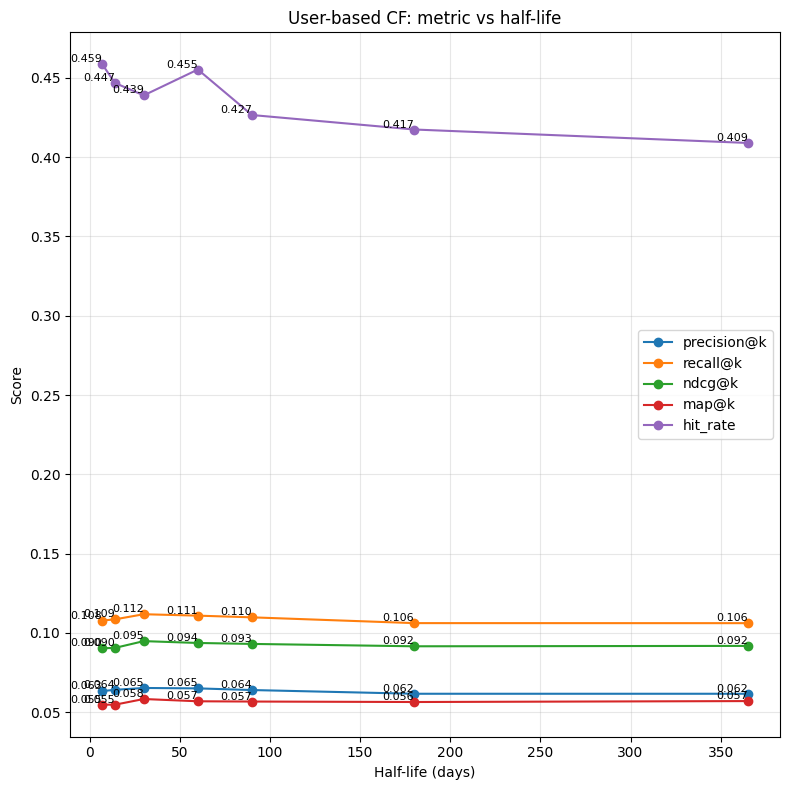

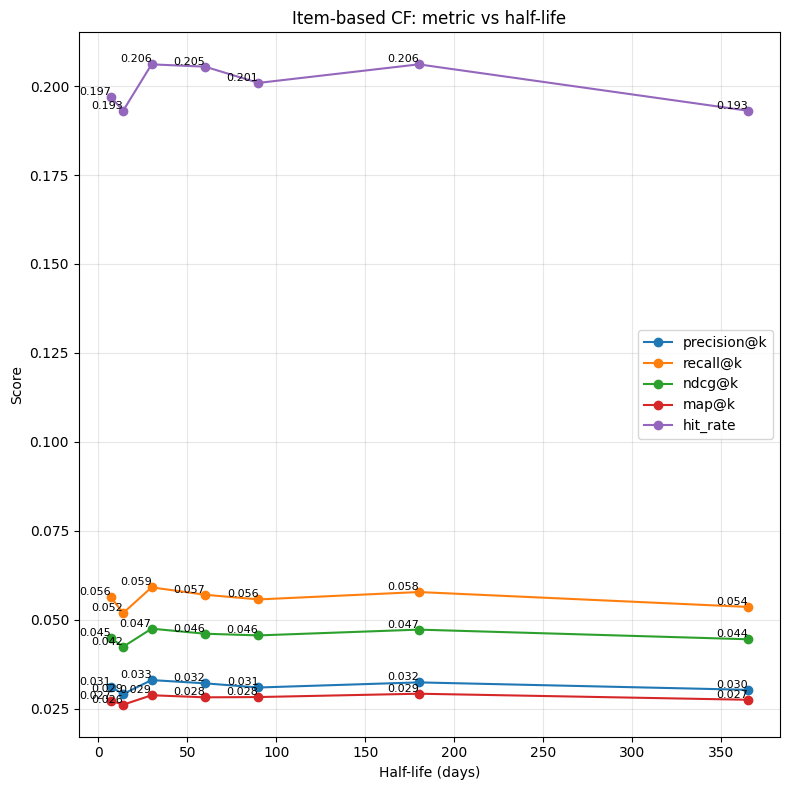

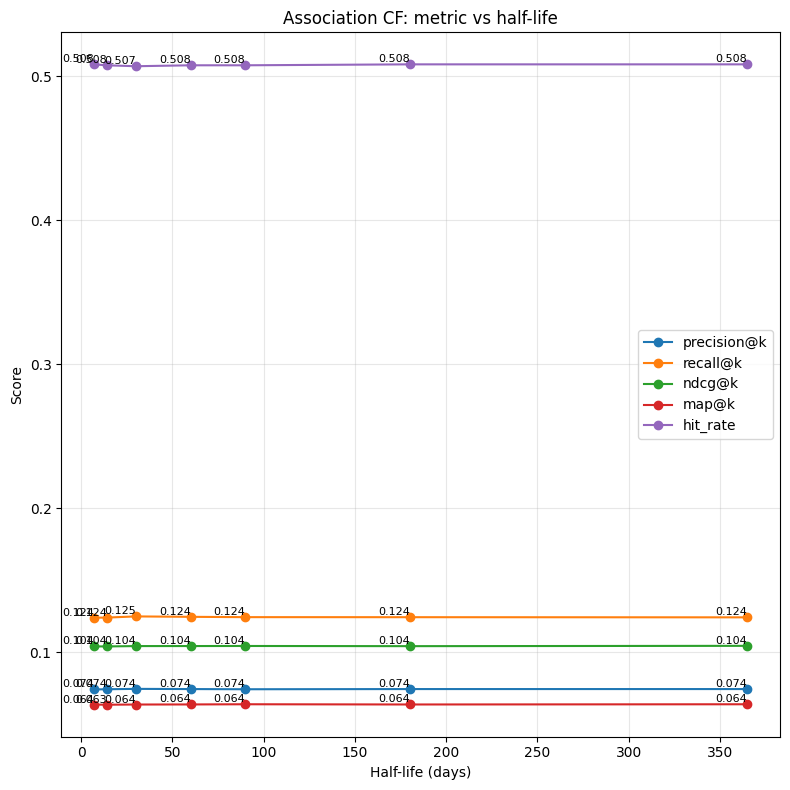

In [64]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_metrics(results_dict, title, metric_order=None, figsize=(8, 8)):
    """
    Draws one square line-chart with every metric in `results_dict`
    (the dict returned by tune_half_life) on the same axes.

    Parameters
    ----------
    results_dict : dict  {half_life: {'precision@k':…, …}}
    title        : str   chart title
    metric_order : list  draw in this order (optional)
    figsize      : tuple figure size, default (8, 8) = square
    """
    if metric_order is None:
        metric_order = ['precision@k', 'recall@k',
                        'ndcg@k', 'map@k', 'hit_rate']

    hl_vals = sorted(results_dict.keys())

    plt.figure(figsize=figsize)
    for m in metric_order:
        y = [results_dict[hl][m] for hl in hl_vals]
        plt.plot(hl_vals, y, marker='o', label=m)
        # annotate the exact numbers at each point
        for x_i, y_i in zip(hl_vals, y):
            plt.text(x_i, y_i, f'{y_i:.3f}', fontsize=8,
                     ha='right', va='bottom')

    plt.title(title)
    plt.xlabel('Half-life (days)')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ── run once for each tuning dict ─────────────────────
plot_all_metrics(user_results,  "User-based CF: metric vs half-life")
plot_all_metrics(item_results,  "Item-based CF: metric vs half-life")
# If you tuned the association-rule variant as well:
plot_all_metrics(assoc_results, "Association CF: metric vs half-life")


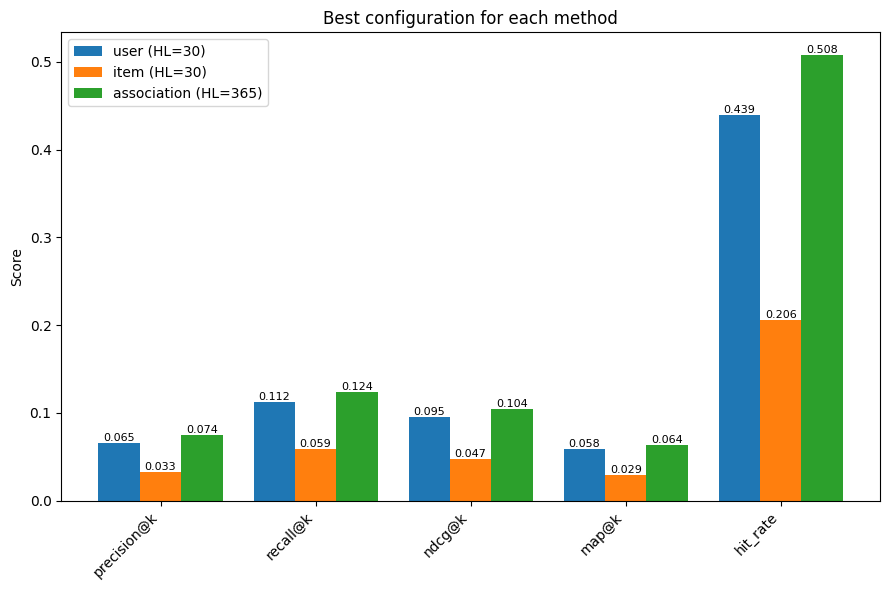

In [65]:
import matplotlib.pyplot as plt
import numpy as np

def best_methods_barchart(best_methods, figsize=(9, 6)):
    """
    best_methods = {'user': (best_hl_user,   best_metrics_dict),
                    'item': (best_hl_item,   …),
                    'association': (best_hl_as, …)}
    """
    metrics = ['precision@k', 'recall@k', 'ndcg@k', 'map@k', 'hit_rate']
    methods  = list(best_methods.keys())
    x        = np.arange(len(metrics))
    width    = 0.8 / len(methods)     # keeps bars inside axis

    plt.figure(figsize=figsize)
    for idx, method in enumerate(methods):
        hl, vals_dict = best_methods[method]
        vals = [vals_dict[m] for m in metrics]
        bars = plt.bar(x + idx*width, vals, width,
                       label=f'{method} (HL={hl})')
        # annotate each bar
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, height,
                     f'{height:.3f}', ha='center', va='bottom', fontsize=8)

    plt.xticks(x + width*(len(methods)-1)/2, metrics, rotation=45, ha='right')
    plt.ylabel('Score')
    plt.title('Best configuration for each method')
    plt.legend()
    plt.tight_layout()
    plt.show()

# ── call after best_methods is built ─────────────────
best_methods_barchart(best_methods)


In [66]:
best_method = max(best_methods.keys(), key=lambda m: best_methods[m][1]['ndcg@k'])
best_half_life = best_methods[best_method][0]

In [70]:
print(f"\nBest method: {best_method}-based with half-life of {best_half_life} days")
print(f"Metrics for best method:")
for metric, value in best_methods[best_method][1].items():
    # Check if the value is a list and calculate the average if it is
    if isinstance(value, list):
        avg_value = sum(value) / len(value) if len(value) > 0 else 0  # Handle empty lists
        print(f"  {metric}: {avg_value:.4f}")
    else:
        print(f"  {metric}: {value:.4f}")


Best method: association-based with half-life of 365 days
Metrics for best method:
  precision@k: 0.0743
  recall@k: 0.1241
  ndcg@k: 0.1044
  map@k: 0.0638
  hit_rate: 0.5082
  user_ndcg@k: 0.1044


In [71]:
test_results = test_on_test_set(
    train_df, test_df, best_half_life, best_method,
    rules_df=rules_df if best_method == 'association' else None,
    top_n=10, k=5
)

In [73]:
print("\nTest set results:")
for metric, value in test_results.items():
    # Check if the value is a list and calculate the average if it is
    if isinstance(value, list):
        avg_value = sum(value) / len(value) if len(value) > 0 else 0  # Handle empty lists
        print(f"  {metric}: {avg_value:.4f}")
    else:
        print(f"  {metric}: {value:.4f}")


Test set results:
  precision@k: 0.1418
  recall@k: 0.1218
  ndcg@k: 0.1559
  map@k: 0.0915
  hit_rate: 0.6936
  user_ndcg@k: 0.1559


In [74]:
user_id = 1004
user_item_matrix = create_user_item_matrix(train_df, half_life_days=best_half_life)

In [75]:
# Generate recommendations based on best method
if best_method == 'user' or best_method == 'item':
    sim_matrix = compute_similarities(user_item_matrix, method=best_method)
    recommendations = generate_recommendations(
        user_item_matrix, sim_matrix, user_id,
        method=best_method, top_n=10
    )
    if recommendations is not None:
        recommended_items = [(item, score) for item, score in recommendations.items()]
    else:
        recommended_items = [(item, 1.0) for item in get_most_popular_items(train_df)]

elif best_method == 'association':
    recommended_items = generate_association_recommendations(
        rules_df, user_item_matrix, user_id, top_n=10
    )
    if not recommended_items:
        recommended_items = [(item, 1.0) for item in get_most_popular_items(train_df)]

print(f"\nTop 5 recommendations for user {user_id} using {best_method}-based CF with half-life {best_half_life}:")
for item, score in recommended_items[:5]:
    print(f"- {item}: {score:.4f}")


Top 5 recommendations for user 1004 using association-based CF with half-life 365:
- soda: 61.0472
- newspapers: 49.2168
- domestic eggs: 42.1207
- sausage: 27.9327
- yogurt: 25.6904


In [ ]:
best_method

In [ ]:
best_half_life

In [92]:
# === Grocery Store Recommender System ===

# === Welcome and README ===
print("""
=======================================
 Welcome to the Grocery Store
 Recommender System!
=======================================
This system provides recommendations using:
- Collaborative Filtering (CF)
- Frequent Pattern Mining (Pattern)
- A Combined Hybrid Approach

Instructions:
- Run all cells from top to bottom.
- Enter a valid User ID when prompted.
- Select the recommendation mode you want (cf, pattern, combined).
- Top-5 recommendations will be displayed!
=======================================
""")

# === Step 1: Load Train and Test Data ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import time

train_df = pd.read_csv('/content/drive/MyDrive/big data mining/assignment 3/Groceries data train.csv')
#Corrected path to the actual test data file
test_df = pd.read_csv('/content/drive/MyDrive/big data mining/assignment 3/Groceries data test.csv')
train_df['date'] = pd.to_datetime(train_df['Date'], format='%d/%m/%Y')
test_df['date'] = pd.to_datetime(test_df['Date'], format='%d/%m/%Y')
print("✅ Train and Test Data Loaded Successfully.")

# === Step 2: Frequent Pattern Mining (Apriori) ===
transactions = train_df.groupby(['User_id', 'Date'])['itemDescription'].apply(list).tolist()
class AprioriMiner:
    def __init__(self, min_support=0.005):
        self.min_support = min_support
        self.frequent_itemsets = {}
        self.item_support = {}

    def fit(self, transactions):
        from itertools import combinations
        item_counts = defaultdict(int)
        for transaction in transactions:
            for item in set(transaction):
                item_counts[item] += 1
        num_transactions = len(transactions)
        min_count = self.min_support * num_transactions
        self.item_support = {item: count for item, count in item_counts.items() if count >= min_count}
        L1 = [(frozenset([item]), count/num_transactions) for item, count in item_counts.items() if count >= min_count]
        self.frequent_itemsets[1] = L1
        k = 2
        current_L = [itemset for itemset, _ in L1]
        while current_L:
            candidate_counts = defaultdict(int)
            for transaction in transactions:
                transaction_items = set(transaction)
                for combo in combinations(current_L, 2):
                    union_set = combo[0] | combo[1]
                    if len(union_set) == k and union_set.issubset(transaction_items):
                        candidate_counts[union_set] += 1
            Lk = [(itemset, count/num_transactions) for itemset, count in candidate_counts.items() if count >= min_count]
            if not Lk:
                break
            self.frequent_itemsets[k] = Lk
            current_L = [itemset for itemset, _ in Lk]
            k += 1

pattern_miner = AprioriMiner(min_support=0.005)
pattern_miner.fit(transactions)

frequent_patterns = []
for size, patterns in pattern_miner.frequent_itemsets.items():
    for itemset, support in patterns:
        if len(itemset) > 1:
            items = list(itemset)
            for i in range(len(items)):
                antecedent = set(items[:i] + items[i+1:])
                consequent = items[i]
                confidence = support / pattern_miner.item_support.get(consequent, 1)
                frequent_patterns.append((antecedent, consequent, round(support, 4), round(confidence, 4)))
print(f"✅ Frequent Patterns Mined. Total patterns found: {len(frequent_patterns)}")

# === Step 3: Fit Collaborative Filtering Recommender ===
from sklearn.metrics.pairwise import cosine_similarity

class CollaborativeFilteringRecommender:
    def __init__(self, recency_weighting=True, decay_factor=0.95):
        self.recency_weighting = recency_weighting
        self.decay_factor = decay_factor
        self.fitted = False

    def fit(self, df):
        # Indentation added for the code within the fit function
        user_item_dict = defaultdict(dict)
        for _, row in df.iterrows():
            user, item, date = row['user_id'], row['itemDescription'], row['Date']
            weight = self.decay_factor ** ((df['Date'].max() - date).days) if self.recency_weighting else 1
            user_item_dict[user][item] = user_item_dict[user].get(item, 0) + weight
        self.user_map = {user: idx for idx, user in enumerate(user_item_dict)}
        self.item_map = {item: idx for idx, item in enumerate(set(i for items in user_item_dict.values() for i in items))}
        self.reverse_item_map = {idx: item for item, idx in self.item_map.items()}

        # Create a DataFrame from user_item_dict
        df_user_item = pd.DataFrame.from_dict(user_item_dict, orient='index').fillna(0)

        # Convert DataFrame to user-item matrix with recency weights
        user_item_matrix = df_user_item.to_numpy()

        self.user_item_matrix = user_item_matrix
        self.user_similarity_matrix = cosine_similarity(user_item_matrix)
        self.fitted = True

    def recommend(self, user_id, top_n=5, exclude_items=None):
        if user_id not in self.user_map:
            return []
        user_idx = self.user_map[user_id]
        user_similarities = self.user_similarity_matrix[user_idx]
        scores = user_similarities @ self.user_item_matrix
        if exclude_items:
            exclude_indices = [self.item_map.get(i) for i in exclude_items if i in self.item_map]
            scores[exclude_indices] = 0
        top_indices = np.argsort(scores)[::-1][:top_n]
        return [self.reverse_item_map[idx] for idx in top_indices if scores[idx] > 0]

# === Step 4: User-Friendly Recommendation Interface ===

def recommend_from_frequent_patterns(user_id, patterns, k=5):
    user_items = set(train_df[train_df['User_id'] == user_id]['itemDescription'])
    scored = []
    for antecedent, consequent, support, confidence in patterns:
        if antecedent.issubset(user_items):
            scored.append((consequent, confidence))
    scored = sorted(scored, key=lambda x: x[1], reverse=True)
    seen = set()
    recommendations = []
    for item, _ in scored:
        if item not in seen:
            recommendations.append(item)
            seen.add(item)
        if len(recommendations) >= k:
            break
    return recommendations

def hybrid_recommend(user_id, patterns, k=5):
    rec_cf = recommender.recommend(user_id, top_n=k)
    rec_pat = recommend_from_frequent_patterns(user_id, patterns, k)
    merged = list(dict.fromkeys(rec_cf + rec_pat))
    return merged[:k]

print("\n=======================================")
print("         START RECOMMENDATION          ")
print("=======================================")

user_id_input = input("Enter a User ID: ").strip()
mode_input = input("Choose mode ('cf', 'pattern', 'combined'): ").strip().lower()

start_time = time.time()

if mode_input == 'cf':
    recommendations = recommender.recommend(user_id_input, top_n=5)
elif mode_input == 'pattern':
    recommendations = recommend_from_frequent_patterns(user_id_input, frequent_patterns, k=5)
elif mode_input == 'combined':
    recommendations = hybrid_recommend(user_id_input, frequent_patterns, k=5)
else:
    recommendations = []
    print("Invalid mode. Please choose 'cf', 'pattern', or 'combined'.")

end_time = time.time()

print("\n🎯 Top-5 Recommendations:")
for i, item in enumerate(recommendations, 1):
    print(f"{i}. {item}")

print(f"\n⏱️ Time Taken: {round(end_time - start_time, 3)} seconds")



 Welcome to the Grocery Store 
 Recommender System!
This system provides recommendations using:
- Collaborative Filtering (CF)
- Frequent Pattern Mining (Pattern)
- A Combined Hybrid Approach

Instructions:
- Run all cells from top to bottom.
- Enter a valid User ID when prompted.
- Select the recommendation mode you want (cf, pattern, combined).
- Top-5 recommendations will be displayed!

✅ Train and Test Data Loaded Successfully.
✅ Frequent Patterns Mined. Total patterns found: 20

         START RECOMMENDATION          
Enter a User ID: 'U1001'
Choose mode ('cf', 'pattern', 'combined'): cf

🎯 Top-5 Recommendations:

⏱️ Time Taken: 0.0 seconds
